In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from figures_setup import *
from utils import set_color_code

## Read data: SMC and KUL cohorts

In [ ]:
# Read input data
file = os.path.join(dir_data, "SMC_epi.h5ad")
smc = sc.read_h5ad(file)

In [4]:
# Read input data
file = os.path.join(dir_data, "KUL_epi.h5ad")
kul = sc.read_h5ad(file)

## Stem cell composition

In [ ]:
# Add LGR5 / TROP2 status
from utils import add_SC_status
smc = add_SC_status(smc)
kul = add_SC_status(kul)

In [11]:
# Set color code and plot barplot
from utils_biobank_tissue import color_code
smc = set_color_code(smc, color_code, feature='SC_status')
kul = set_color_code(kul, color_code, feature='SC_status')

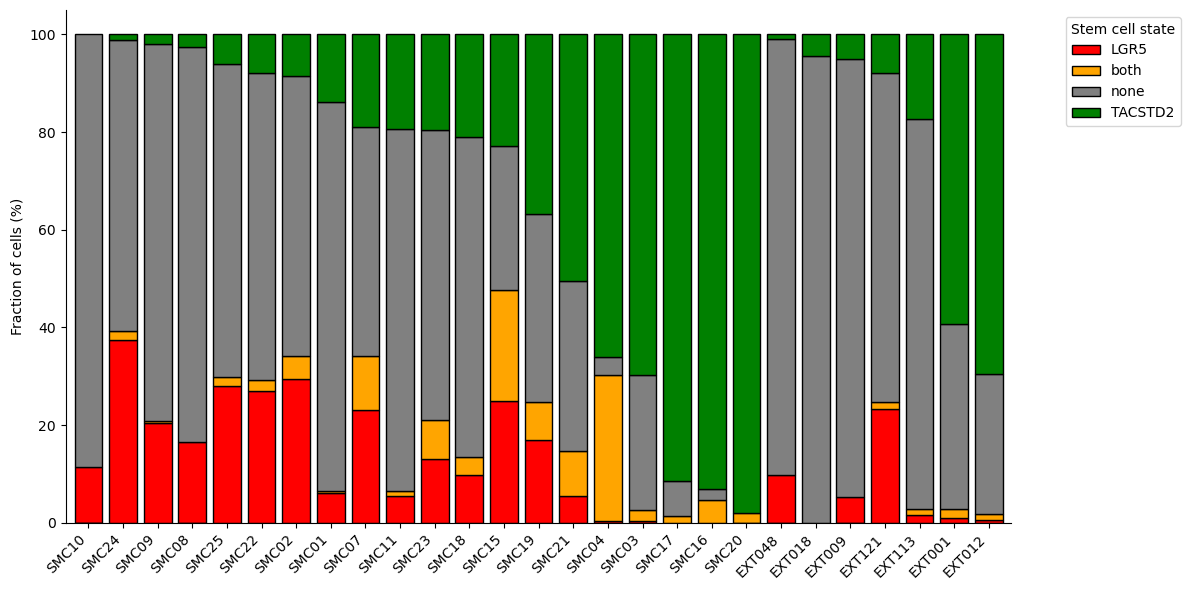

In [15]:
groupby = 'Patient ID'

# Map full donor IDs
from utils import full_donor_id_dict
# from utils_biobank_tissue import order_donor_id

# SC status as bar graph by grouping parameter
df_smc = (
    smc.obs.groupby(groupby)['SC_status']
    .value_counts(normalize=True)
    .unstack(fill_value=0)
    *100 # percentage values
)
df_smc = df_smc.sort_values(by='TACSTD2', ascending=True)

df_kul = (
    kul.obs.groupby(groupby)['SC_status']
    .value_counts(normalize=True)
    .unstack(fill_value=0)
    *100 # percentage values
)
df_kul = df_kul.sort_values(by='TACSTD2', ascending=True)

# Combine both datasets
df = pd.concat([df_smc, df_kul], axis=0)

# # Sort DataFrame based on predefined donor order
# df = df.reindex(order_donor_id)

# Barplot mimicking Fig S1M
# Values were plotted with GraphPad Prism in the original figure
ax = df.plot(
    kind='bar', 
    stacked=True, 
    edgecolor='black',
    color=color_code['SC_status']['colors'],
    figsize=(12, 6), 
    width=0.8,
)
plt.xlabel('')
plt.ylabel('Fraction of cells (%)')
# Change x-ticks and labels
ax.set_xticklabels([donor.split("-")[0] for donor in df.index])
plt.xticks(rotation=45, ha='right')
plt.legend(title='Stem cell state', bbox_to_anchor=(1.05, 1), loc='upper left')
# Remove box frame, keep axes
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()